# **Day 32: Support Vector Machines**
*Module 5 - Classification*

SVMs find the boundary with the **largest margin** between classes. With the **kernel trick** they draw complex non-linear boundaries while solving a convex problem. They excel with **small-to-medium datasets and many features** (hyperspectral pixels, text, genomics) and were the dominant remote-sensing classifier before Random Forests.

> A support vector machine finds the boundary that separates classes with the widest possible margin. With kernels it can draw curved boundaries. SVMs work well with small training sets and many features.
>
> *Example:* With only 30 labelled samples per class and 10 bands, an RBF-kernel SVM often separates urban, water and vegetation very well.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
rng = np.random.default_rng(32)

def plot_svm(ax, model, X, y, title=""):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300), np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=30, cmap="RdBu_r", alpha=0.35)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
    ax.scatter(*X.T, c=y, cmap="RdBu_r", s=14, edgecolor="k", lw=0.3)
    sv = model.support_vectors_ if hasattr(model, "support_vectors_") else model[-1].support_vectors_
    ax.scatter(*sv.T, s=80, facecolors="none", edgecolors="lime", lw=1.5)
    ax.set_title(title)

## **1. Maximum Margin**
Many lines separate two clusters. The SVM chooses the one farthest from the closest points. Those closest points are the **support vectors**; the boundary depends only on them.

Hard-margin problem: $\min_{\mathbf w,b}\frac12\lVert\mathbf w\rVert^2$ subject to $y_i(\mathbf w^\top\mathbf x_i+b)\ge 1$. The margin width is $2/\lVert\mathbf w\rVert$.

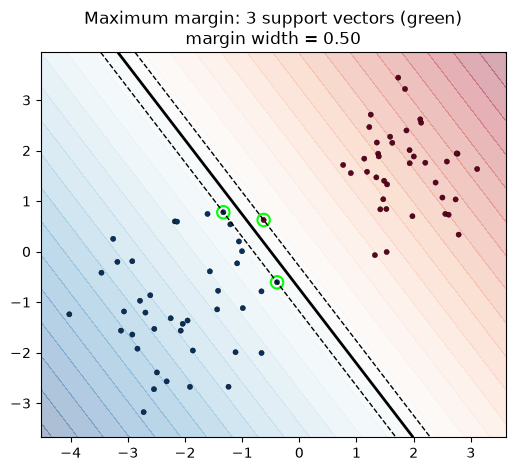

In [2]:
from sklearn.datasets import make_blobs
Xb, yb = make_blobs(80, centers=[[-2, -1], [2, 1.5]], cluster_std=0.9, random_state=3)
svm_lin = SVC(kernel="linear", C=1000).fit(Xb, yb)
fig, ax = plt.subplots(figsize=(6, 5))
plot_svm(ax, svm_lin, Xb, yb, f"Maximum margin: {len(svm_lin.support_)} support vectors (green)\nmargin width = {2 / np.linalg.norm(svm_lin.coef_):.2f}")
plt.show()

## **2. Soft Margin and C**
Real data overlap. The **soft-margin** SVM allows violations $\xi_i$:
$$\min \frac12\lVert\mathbf w\rVert^2 + C\sum_i\xi_i \quad\Leftrightarrow\quad \min\frac12\lVert\mathbf w\rVert^2 + C\sum_i\max\big(0, 1 - y_i f(\mathbf x_i)\big)$$
The second form is the **hinge loss** (Day 14). **Large C**: few violations, narrow margin (may overfit). **Small C**: wide margin, more violations (more regularisation).

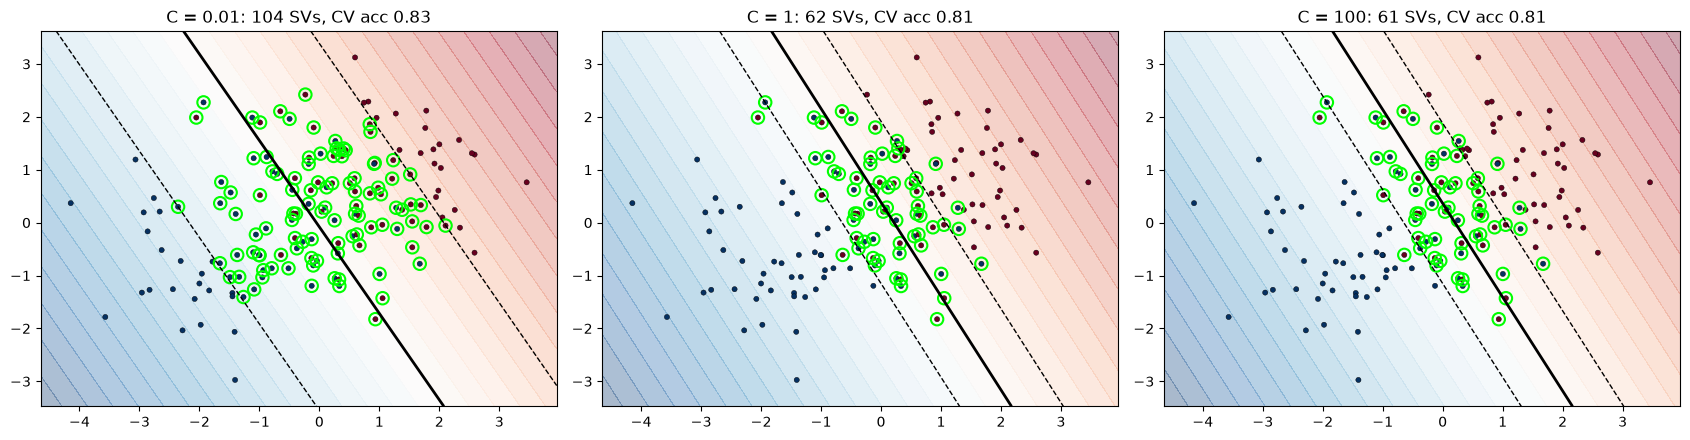

In [3]:
Xo, yo = make_blobs(150, centers=[[-1, -0.5], [1, 0.8]], cluster_std=1.1, random_state=5)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, C in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel="linear", C=C).fit(Xo, yo)
    plot_svm(ax, m, Xo, yo, f"C = {C}: {len(m.support_)} SVs, CV acc {cross_val_score(SVC(kernel='linear', C=C), Xo, yo, cv=5).mean():.2f}")
plt.tight_layout(); plt.show()

## **3. Kernels and the Kernel Trick**
The SVM solution depends on the data only through **dot products** $\mathbf x_i^\top\mathbf x_j$. Replace them by a **kernel** $K(\mathbf x_i,\mathbf x_j) = \phi(\mathbf x_i)^\top\phi(\mathbf x_j)$, and the SVM works in a high- (even infinite-) dimensional feature space without ever computing $\phi$.

| Kernel | $K(\mathbf x,\mathbf z)$ | Parameters |
|---|---|---|
| Linear | $\mathbf x^\top\mathbf z$ | C |
| Polynomial | $(\gamma\mathbf x^\top\mathbf z + r)^d$ | C, degree, gamma, coef0 |
| **RBF (Gaussian)** | $\exp(-\gamma\lVert\mathbf x-\mathbf z\rVert^2)$ | C, gamma |
| Sigmoid | $\tanh(\gamma\mathbf x^\top\mathbf z + r)$ | rarely used |

### Explicit feature map vs kernel: same numbers

In [4]:
x, z = rng.normal(size=2), rng.normal(size=2)
phi = lambda v: np.array([v[0] ** 2, v[1] ** 2, np.sqrt(2) * v[0] * v[1], np.sqrt(2) * v[0], np.sqrt(2) * v[1], 1.0])
print(f"phi(x).phi(z) = {phi(x) @ phi(z):.6f} | (x.z + 1)^2 = {(x @ z + 1) ** 2:.6f}")

phi(x).phi(z) = 2.152302 | (x.z + 1)^2 = 2.152302


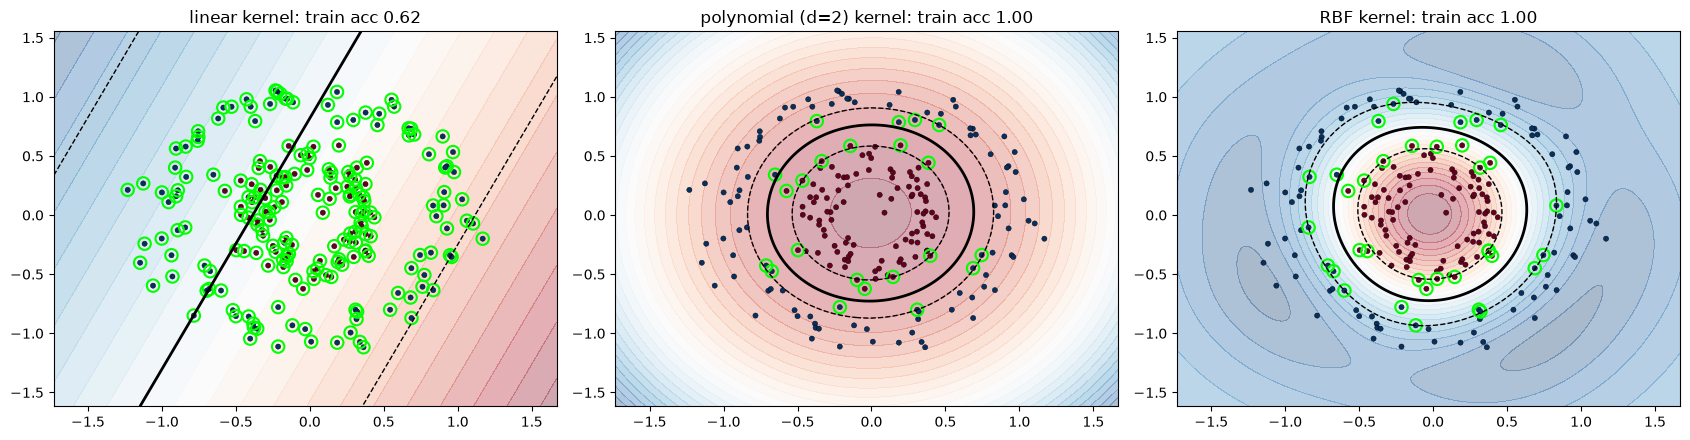

In [5]:
from sklearn.datasets import make_circles, make_moons
Xc, yc = make_circles(200, noise=0.1, factor=0.4, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (name, m) in zip(axes, {"linear": SVC(kernel="linear"), "polynomial (d=2)": SVC(kernel="poly", degree=2, coef0=1), "RBF": SVC(kernel="rbf")}.items()):
    m.fit(Xc, yc); plot_svm(ax, m, Xc, yc, f"{name} kernel: train acc {m.score(Xc, yc):.2f}")
plt.tight_layout(); plt.show()

### Gamma: how far each training point's influence reaches
Large $\gamma$ = narrow Gaussians = wiggly boundary (overfits). Small $\gamma$ = smooth boundary.

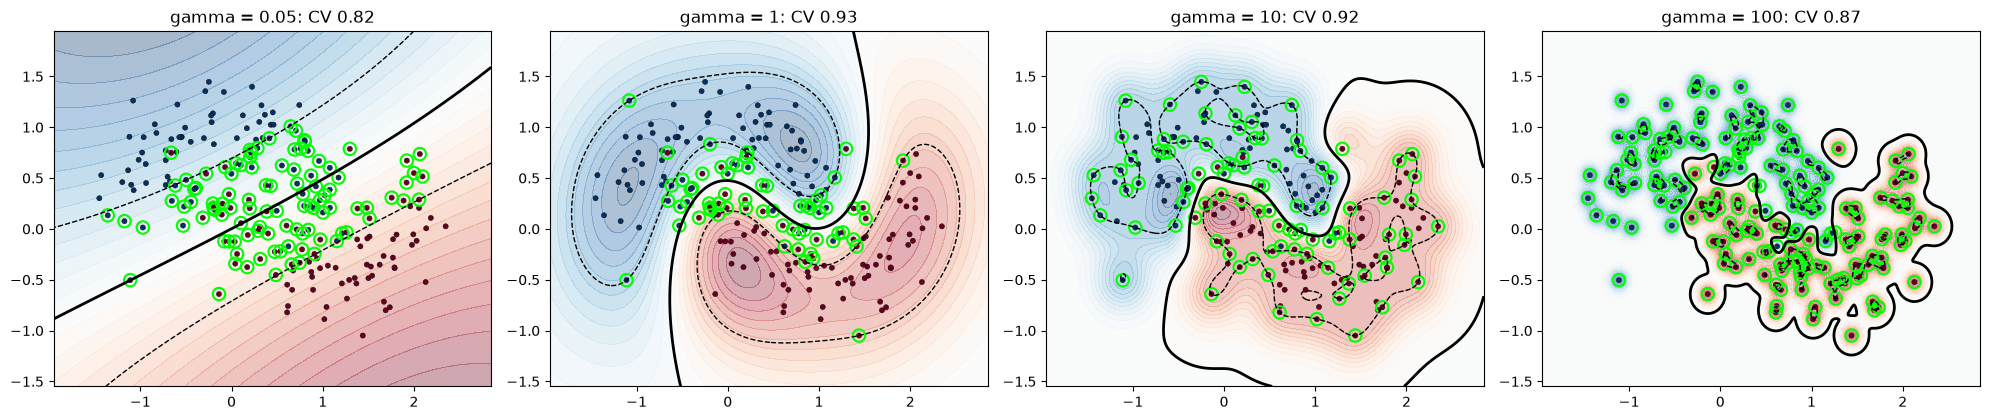

In [6]:
Xm, ym = make_moons(200, noise=0.25, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, g in zip(axes, [0.05, 1, 10, 100]):
    m = SVC(kernel="rbf", gamma=g, C=1).fit(Xm, ym)
    plot_svm(ax, m, Xm, ym, f"gamma = {g}: CV {cross_val_score(SVC(gamma=g), Xm, ym, cv=5).mean():.2f}")
plt.tight_layout(); plt.show()

## **4. Tuning C and Gamma (Always Scale First!)**
C and gamma interact: search them jointly on a **log grid**.

RBF SVM without scaling: 0.912


Tuned, scaled RBF SVM : 0.979 {'svc__C': 31.6228, 'svc__gamma': 0.01}


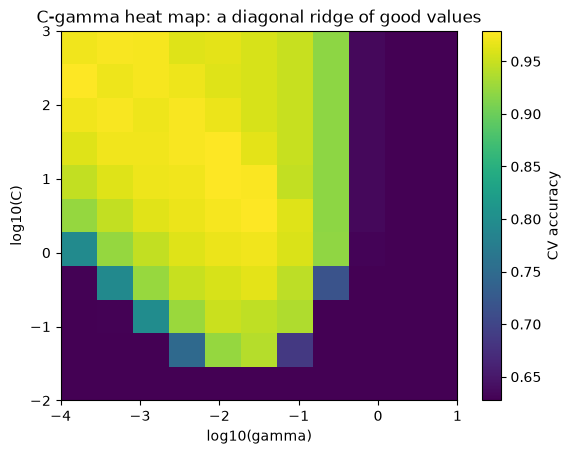

In [7]:
from sklearn.datasets import load_breast_cancer
Xbc, ybc = load_breast_cancer(return_X_y=True)
print("RBF SVM without scaling:", cross_val_score(SVC(), Xbc, ybc, cv=5).mean().round(3))
pipe = make_pipeline(StandardScaler(), SVC())
gs = GridSearchCV(pipe, {"svc__C": np.logspace(-2, 3, 11), "svc__gamma": np.logspace(-4, 1, 11)}, cv=5, n_jobs=-1).fit(Xbc, ybc)
print("Tuned, scaled RBF SVM :", round(gs.best_score_, 3), {k: round(float(v), 4) for k, v in gs.best_params_.items()})
scores = gs.cv_results_["mean_test_score"].reshape(11, 11)
plt.imshow(scores, origin="lower", cmap="viridis", aspect="auto", extent=[-4, 1, -2, 3])
plt.colorbar(label="CV accuracy"); plt.xlabel("log10(gamma)"); plt.ylabel("log10(C)"); plt.title("C-gamma heat map: a diagonal ridge of good values"); plt.show()

## **5. Support Vector Regression**
SVR fits a tube of width $\varepsilon$ around the function; errors inside the tube cost nothing (epsilon-insensitive loss), giving robustness and sparsity.

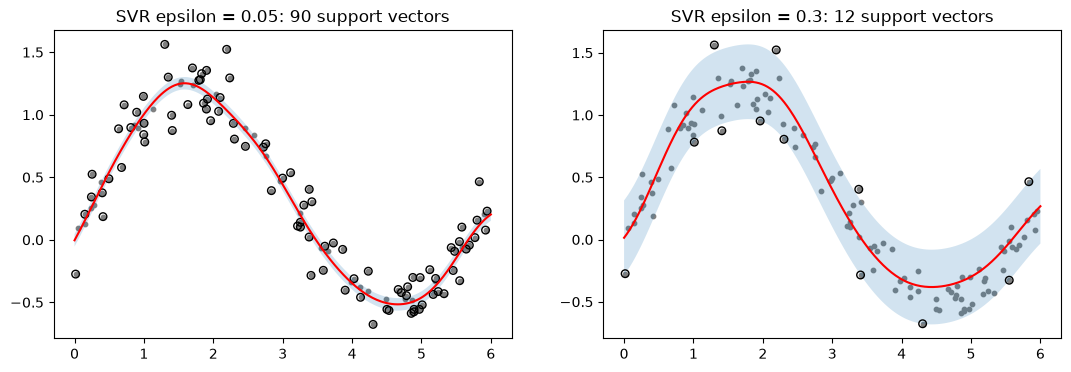

In [8]:
xr = np.sort(rng.uniform(0, 6, 120)); yr = np.sin(xr) + 0.1 * xr + rng.normal(0, 0.15, 120)
g = np.linspace(0, 6, 300)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, eps in zip(axes, [0.05, 0.3]):
    svr = SVR(C=10, epsilon=eps, gamma=1).fit(xr[:, None], yr); pr = svr.predict(g)
    ax.scatter(xr, yr, s=10, c="grey"); ax.plot(g, pr, "r"); ax.fill_between(g.ravel(), pr - eps, pr + eps, alpha=0.2)
    ax.scatter(xr[svr.support_], yr[svr.support_], s=30, facecolors="none", edgecolors="k")
    ax.set_title(f"SVR epsilon = {eps}: {len(svr.support_)} support vectors")
plt.show()

## **6. Multi-Class and Probabilities**
SVMs are binary. `SVC` uses **one-vs-one** internally ($K(K-1)/2$ classifiers); `LinearSVC` uses one-vs-rest. For probabilities, wrap the SVM in `CalibratedClassifierCV(SVC(), ensemble=False)` (Platt scaling with internal CV, Day 29). The old `SVC(probability=True)` option is deprecated since scikit-learn 1.9.

In [9]:
from sklearn.datasets import load_digits
Xd, yd = load_digits(return_X_y=True)
for name, m in {"LinearSVC": make_pipeline(StandardScaler(), LinearSVC(C=0.01, max_iter=5000)),
                "SVC linear": make_pipeline(StandardScaler(), SVC(kernel="linear", C=0.01)),
                "SVC RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10))}.items():
    print(f"{name:<11} digits CV accuracy {cross_val_score(m, Xd, yd, cv=5).mean():.3f}")

LinearSVC   digits CV accuracy 0.912
SVC linear  digits CV accuracy 0.940


SVC RBF     digits CV accuracy 0.951


# **Part 2: Going Deeper**

### The dual problem
Using Lagrange multipliers (Day 13), the soft-margin SVM becomes
$$\max_{\boldsymbol\alpha}\sum_i\alpha_i - \frac12\sum_{i,j}\alpha_i\alpha_jy_iy_jK(\mathbf x_i,\mathbf x_j),\quad 0\le\alpha_i\le C,\quad\sum_i\alpha_iy_i = 0$$
Prediction: $f(\mathbf x) = \sum_i\alpha_iy_iK(\mathbf x_i,\mathbf x) + b$. Only points with $\alpha_i > 0$ (support vectors) matter. Let us verify this formula against scikit-learn.

In [10]:
m = SVC(kernel="rbf", gamma=0.5, C=1).fit(Xm, ym)
K = np.exp(-0.5 * ((Xm[:5, None, :] - m.support_vectors_[None]) ** 2).sum(-1))       # K(x, sv)
f_manual = K @ m.dual_coef_.ravel() + m.intercept_                                     # dual_coef_ = alpha_i * y_i
print("manual decision function :", f_manual.round(4))
print("sklearn decision_function:", m.decision_function(Xm[:5]).round(4))

manual decision function : [-0.7583  1.6177  0.0805 -0.8263  1.562 ]
sklearn decision_function: [-0.7583  1.6177  0.0805 -0.8263  1.562 ]


### A linear SVM from scratch (Pegasos-style sub-gradient descent)
Primal objective: $\frac{\lambda}{2}\lVert\mathbf w\rVert^2 + \frac1n\sum\max(0, 1 - y_i\mathbf w^\top\mathbf x_i)$. Sub-gradient: $\lambda\mathbf w - \frac1n\sum_{i: y_if_i<1}y_i\mathbf x_i$.

In [11]:
def linear_svm_sgd(X, y, lam=0.01, epochs=200, seed=0):
    r = np.random.default_rng(seed); y_pm = np.where(y == 1, 1, -1); Xa = np.c_[X, np.ones(len(X))]
    w = np.zeros(Xa.shape[1]); t = 0
    for ep in range(epochs):
        for i in r.permutation(len(X)):
            t += 1; eta = 1 / (lam * t)
            if y_pm[i] * Xa[i] @ w < 1:
                w = (1 - eta * lam) * w + eta * y_pm[i] * Xa[i]
            else:
                w = (1 - eta * lam) * w
    return w

Xs_bc = StandardScaler().fit_transform(Xbc)
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xs_bc, ybc, test_size=0.3, random_state=0)
w = linear_svm_sgd(Xa_tr, ya_tr, epochs=30)
acc = np.mean((np.c_[Xa_te, np.ones(len(Xa_te))] @ w > 0).astype(int) == ya_te)
print(f"Scratch linear SVM test accuracy {acc:.3f} | LinearSVC {LinearSVC(C=1 / (0.01 * len(ya_tr)), max_iter=10000).fit(Xa_tr, ya_tr).score(Xa_te, ya_te):.3f}")

Scratch linear SVM test accuracy 0.971 | LinearSVC 0.953


### Scaling to big data
Kernel SVM training costs between $O(n^2)$ and $O(n^3)$: impractical beyond ~50,000 samples. Options: `LinearSVC` / `SGDClassifier(loss="hinge")` (linear, millions of samples), or **approximate kernel features** (`Nystroem`, `RBFSampler`) followed by a linear SVM.

In [12]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
import time
Xbig, ybig = make_moons(60000, noise=0.25, random_state=0)
Xbig_tr, Xbig_te, ybig_tr, ybig_te = train_test_split(Xbig, ybig, test_size=0.2, random_state=0)
for name, m in {"SVC RBF (10k subset)": SVC(gamma=1), "Nystroem(300) + linear SGD (all 48k)": make_pipeline(Nystroem(gamma=1, n_components=300, random_state=0), SGDClassifier(loss="hinge", random_state=0))}.items():
    t = time.perf_counter(); n_use = 10000 if "subset" in name else len(ybig_tr)
    m.fit(Xbig_tr[:n_use], ybig_tr[:n_use]); print(f"{name:<38} test acc {m.score(Xbig_te, ybig_te):.3f} in {time.perf_counter() - t:.1f}s")

SVC RBF (10k subset)                   test acc 0.940 in 0.9s


Nystroem(300) + linear SGD (all 48k)   test acc 0.940 in 0.5s


## **Practice Problems**
1. On `make_moons(noise=0.3)`, tune an RBF SVM with `RandomizedSearchCV` over log-uniform C and gamma.
2. Count the support vectors of the tuned breast-cancer SVM. What fraction of the training data is it?
3. Show that the RBF kernel matrix is positive semi-definite (all eigenvalues >= 0).
4. *(Advanced)* Implement the primal objective and plot it over epochs for our Pegasos SVM.

best: {'svc__C': 10.323, 'svc__gamma': 0.53} CV 0.92
60 support vectors = 10.5% of training data
min eigenvalue of RBF kernel matrix: -0.0


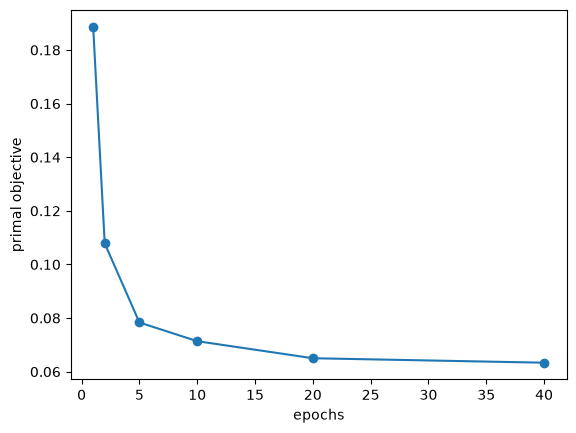

In [13]:
# Solution 1
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
X1, y1 = make_moons(300, noise=0.3, random_state=1)
rs = RandomizedSearchCV(make_pipeline(StandardScaler(), SVC()), {"svc__C": loguniform(1e-2, 1e3), "svc__gamma": loguniform(1e-3, 1e2)},
                        n_iter=40, cv=5, random_state=0).fit(X1, y1)
print("best:", {k: round(float(v), 3) for k, v in rs.best_params_.items()}, "CV", round(rs.best_score_, 3))
# Solution 2
best_svc = gs.best_estimator_[-1]
print(f"{best_svc.n_support_.sum()} support vectors = {best_svc.n_support_.sum() / len(ybc):.1%} of training data")
# Solution 3
Kmat = np.exp(-0.5 * ((Xm[:, None] - Xm[None]) ** 2).sum(-1))
print("min eigenvalue of RBF kernel matrix:", np.linalg.eigvalsh(Kmat).min().round(10))
# Solution 4
def primal(w, X, y, lam=0.01):
    ypm = np.where(y == 1, 1, -1); Xa = np.c_[X, np.ones(len(X))]
    return lam / 2 * w @ w + np.mean(np.maximum(0, 1 - ypm * (Xa @ w)))
objs = [primal(linear_svm_sgd(Xa_tr, ya_tr, epochs=e), Xa_tr, ya_tr) for e in [1, 2, 5, 10, 20, 40]]
plt.plot([1, 2, 5, 10, 20, 40], objs, "o-"); plt.xlabel("epochs"); plt.ylabel("primal objective"); plt.show()

## **Key References**
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273-297.
- Scholkopf, B., & Smola, A. J. (2002). *Learning with Kernels*. MIT Press.
- Hsu, C.-W., Chang, C.-C., & Lin, C.-J. (2003). A practical guide to support vector classification. Technical report, National Taiwan University.
- Shalev-Shwartz, S., Singer, Y., & Srebro, N. (2007). Pegasos: Primal estimated sub-gradient solver for SVM. *ICML 2007*.
- Mountrakis, G., Im, J., & Ogole, C. (2011). Support vector machines in remote sensing: A review. *ISPRS Journal of Photogrammetry and Remote Sensing*, 66(3), 247-259.
- Williams, C., & Seeger, M. (2001). Using the Nystrom method to speed up kernel machines. *NeurIPS 13*.